In [1]:
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sqlalchemy
from scipy.stats import chi2_contingency
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import LabelEncoder
from matplotlib.lines import Line2D

warnings.filterwarnings('ignore')

host = os.environ.get('POSTGRES_HOST', 'postgres')
user = os.environ.get('POSTGRES_USER', 'postgres')
password = os.environ.get('POSTGRES_PASSWORD', 'postgres')
db = os.environ.get('POSTGRES_DB', 'etl_db')

engine = sqlalchemy.create_engine(f'postgresql+psycopg2://{user}:{password}@{host}/{db}')
print('Ühendus loodud')

Ühendus loodud


# Tabelite struktuur ja ülevaade

In [2]:
df = pd.read_sql('SELECT * FROM raw_marts.dim_patients', engine)
df.head()

,patient_id,birthdate,gender,city,state,lat,lon,deceased_datetime,is_deceased,age_at_death
0,3cc431be-97eb-1343-3d19-b7482266adae,1967-02-11,male,South Gate,CA,33.937221,-118.217454,NaT,False,NaN
1,ea8df98b-6ed8-2f53-9f6a-80af4fa3bd0f,1951-08-11,female,Barnstable,MA,41.650735,-70.379278,NaT,False,NaN
2,e75202e1-7e34-d68e-3536-2ab1949254a4,1971-09-23,male,Somerville,MA,42.431511,-71.146027,NaT,False,NaN
3,302274e7-106b-0094-e3b1-f6ae75047c08,1992-04-30,male,Huntington Park,CA,33.965380,-118.213251,NaT,False,NaN
4,307ab11f-ff8e-63d6-fb00-b97e91b2234e,1967-11-26,female,Waltham,MA,42.413296,-71.192127,2026-04-30 10:06:33+00:00,True,58.0


In [3]:
df.describe(include='all')

,patient_id,birthdate,gender,city,state,lat,lon,deceased_datetime,is_deceased,age_at_death
count,22761,22761,22761,22761,22761,22761.000000,22761.000000,2757,22761,2757.000000
unique,22761,14639,2,1208,2,NaN,NaN,NaN,2,NaN
top,3cc431be-97eb-1343-3d19-b7482266adae,1939-07-09,female,Los Angeles,MA,NaN,NaN,NaN,False,NaN
freq,1,12,11427,1209,11505,NaN,NaN,NaN,20004,NaN
mean,NaN,NaN,NaN,NaN,NaN,38.874743,-95.088873,2005-12-14 00:33:10.986216960+00:00,NaN,53.845484
min,NaN,NaN,NaN,NaN,NaN,32.504648,-124.366643,1921-06-22 07:57:42+00:00,NaN,0.000000
25%,NaN,NaN,NaN,NaN,NaN,34.195425,-118.388477,1997-01-19 11:51:19+00:00,NaN,42.000000
50%,NaN,NaN,NaN,NaN,NaN,41.567518,-73.223811,2010-09-05 03:00:49+00:00,NaN,57.000000
75%,NaN,NaN,NaN,NaN,NaN,42.310044,-71.148216,2019-09-17 10:28:53+00:00,NaN,70.000000
max,NaN,NaN,NaN,NaN,NaN,42.895369,-69.927128,2026-05-22 16:39:19+00:00,NaN,110.000000


In [4]:
df.dtypes

patient_id                        object
birthdate                         object
gender                            object
city                              object
state                             object
lat                              float64
lon                              float64
deceased_datetime    datetime64[ns, UTC]
is_deceased                         bool
age_at_death                     float64
dtype: object

In [5]:
df_diagnosis = pd.read_sql('SELECT * FROM raw_marts.dim_diagnosis', engine)
df_diagnosis.head()

,icd10_code,snomed_code,diagnosis_name
0,M05.9,239791005,Seropositiivne reumatoidartriit (täpsustamata)
1,M06.9,69896004,Reumatoidartriit (täpsustamata)
2,M10,90560007,Podagra (Gout)
3,M13.9,3723001,Artriit (täpsustamata)
4,M15,201834006,Polüartroos


In [6]:
df_diagnosis.describe(include='all')

,icd10_code,snomed_code,diagnosis_name
count,24,24,24
unique,23,21,23
top,M16,64217002,Puusaliigese artroos (Coxarthrosis)
freq,2,2,2


In [7]:
df_diagnosis.dtypes

icd10_code        object
snomed_code       object
diagnosis_name    object
dtype: object

In [8]:
df_weather = pd.read_sql('SELECT * FROM raw_marts.dim_weather_category', engine)
df_weather.head()

,weather_category_key,rain_flag,temp_category,pressure_category,combined_weather_type
0,1,False,jahe,kõrge,kuiv-jahe-kõrge
1,2,False,jahe,madal,kuiv-jahe-madal
2,3,False,jahe,normaalne,kuiv-jahe-normaalne
3,4,False,külm,kõrge,kuiv-külm-kõrge
4,5,False,külm,madal,kuiv-külm-madal


In [9]:
df_weather.describe(include='all')

,weather_category_key,rain_flag,temp_category,pressure_category,combined_weather_type
count,21.000000,21,21,21,21
unique,NaN,2,4,3,21
top,NaN,True,jahe,kõrge,kuiv-jahe-kõrge
freq,NaN,11,6,8,1
mean,11.000000,NaN,NaN,NaN,NaN
std,6.204837,NaN,NaN,NaN,NaN
min,1.000000,NaN,NaN,NaN,NaN
25%,6.000000,NaN,NaN,NaN,NaN
50%,11.000000,NaN,NaN,NaN,NaN
75%,16.000000,NaN,NaN,NaN,NaN


In [10]:
df_weather.dtypes

weather_category_key      int64
rain_flag                  bool
temp_category            object
pressure_category        object
combined_weather_type    object
dtype: object

In [11]:
df_date = pd.read_sql('SELECT * FROM raw_marts.dim_date', engine)
df_date.head()

,date_key,full_date,year,month,day
0,19480206,1948-02-06,1948,2,6
1,19480207,1948-02-07,1948,2,7
2,19480208,1948-02-08,1948,2,8
3,19480209,1948-02-09,1948,2,9
4,19480210,1948-02-10,1948,2,10


In [12]:
df_date.describe(include='all')

,date_key,full_date,year,month,day
count,2.859700e+04,28597,28597.000000,28597.000000,28597.000000
unique,NaN,28597,NaN,NaN,NaN
top,NaN,1948-02-06,NaN,NaN,NaN
freq,NaN,1,NaN,NaN,NaN
mean,1.986812e+07,NaN,1986.745638,6.511522,15.727943
std,2.260339e+05,NaN,22.603790,3.447889,8.798011
min,1.948021e+07,NaN,1948.000000,1.000000,1.000000
25%,1.967090e+07,NaN,1967.000000,4.000000,8.000000
50%,1.987033e+07,NaN,1987.000000,7.000000,16.000000
75%,2.006103e+07,NaN,2006.000000,10.000000,23.000000


In [13]:
df_date.dtypes

date_key      int64
full_date    object
year          int64
month         int64
day           int64
dtype: object

In [14]:
df_patient_day = pd.read_sql('SELECT * FROM raw_marts.fct_patient_day', engine)
df_patient_day.head()

,patient_day_key,patient_id,date_key,region_key,weather_category_key
0,1,004d47d8-db8c-9540-1b89-5a650532f8c5,19910310,277,16.0
1,2,006b4ba9-5401-b549-8a78-81ebfdc104bc,20220129,226,16.0
2,3,00963a93-e3f4-7f5e-0934-0642322de339,19990615,301,8.0
3,4,00963a93-e3f4-7f5e-0934-0642322de339,20180511,301,10.0
4,5,00963a93-e3f4-7f5e-0934-0642322de339,20240220,301,4.0


In [15]:
df_patient_day.describe(include='all')

,patient_day_key,patient_id,date_key,region_key,weather_category_key
count,1761.000000,1761,1.761000e+03,1761.000000,1598.000000
unique,NaN,1664,NaN,NaN,NaN
top,NaN,dbbb1d00-332b-1524-1d6b-e9f85695b2cb,NaN,NaN,NaN
freq,NaN,4,NaN,NaN,NaN
mean,881.000000,NaN,2.005827e+07,199.141397,10.165207
std,508.501229,NaN,1.577116e+05,86.838100,5.330316
min,1.000000,NaN,1.948021e+07,1.000000,1.000000
25%,441.000000,NaN,1.997112e+07,137.000000,8.000000
50%,881.000000,NaN,2.009123e+07,228.000000,10.000000
75%,1321.000000,NaN,2.018070e+07,270.000000,13.000000


In [16]:
df_patient_day.dtypes

patient_day_key           int64
patient_id               object
date_key                  int64
region_key                int64
weather_category_key    float64
dtype: object

In [17]:
df_weather_region = pd.read_sql('SELECT * FROM raw_marts.fct_weather_region_day', engine)
df_weather_region.head()

,weather_region_day_key,date_key,region_key,precipitation_mm,temperature_avg,pressure_avg,rainy_day_flag,weather_category_key
0,1,20150713,1,0.0,19.2,1015.6,False,10
1,2,20210220,2,0.0,12.9,1019.4,False,10
2,3,20020527,3,0.0,17.8,1014.5,False,10
3,4,20030822,3,0.0,22.8,1013.7,False,8
4,5,20061203,3,0.0,19.4,1023.5,False,9


In [18]:
df_weather_region.describe(include='all')

,weather_region_day_key,date_key,region_key,precipitation_mm,temperature_avg,pressure_avg,rainy_day_flag,weather_category_key
count,5018.000000,5.018000e+03,5018.000000,4829.000000,4792.000000,4616.000000,5018,5018.000000
unique,NaN,NaN,NaN,NaN,NaN,NaN,2,NaN
top,NaN,NaN,NaN,NaN,NaN,NaN,False,NaN
freq,NaN,NaN,NaN,NaN,NaN,NaN,3728,NaN
mean,2509.500000,2.006865e+07,185.001594,1.718658,13.721473,1015.591031,NaN,10.003986
std,1448.716156,1.525680e+05,85.577390,5.796153,8.526602,6.039173,NaN,5.055363
min,1.000000,1.948021e+07,1.000000,0.000000,-19.400000,990.200000,NaN,1.000000
25%,1255.250000,1.999063e+07,107.000000,0.000000,8.600000,1012.100000,NaN,8.000000
50%,2509.500000,2.011022e+07,182.000000,0.000000,15.100000,1015.100000,NaN,10.000000
75%,3763.750000,2.019013e+07,258.000000,0.000000,20.100000,1019.000000,NaN,11.000000


In [19]:
df_weather_region.dtypes

weather_region_day_key      int64
date_key                    int64
region_key                  int64
precipitation_mm          float64
temperature_avg           float64
pressure_avg              float64
rainy_day_flag               bool
weather_category_key        int64
dtype: object

In [20]:
df_patient_weather = pd.read_sql('SELECT * FROM raw_marts.fct_patient_weather_region', engine)
df_patient_weather.head()

,patient_weather_key,patient_id,snomed_code,date_key,region_key,encounter_id,condition_start,condition_end,pain_related_flag,rainy_day_flag,weather_category_key,condition_clinical
0,1,000406a4-08e3-afbe-e18b-efc65ac83cf3,68962001,NaN,NaN,None,2021-04-03,2021-05-09,None,None,NaN,resolved
1,2,000406a4-08e3-afbe-e18b-efc65ac83cf3,57676002,NaN,NaN,None,2021-04-03,2021-05-09,None,None,NaN,resolved
2,3,004d47d8-db8c-9540-1b89-5a650532f8c5,201834006,19910310.0,277.0,004d47d8-db8c-9540-ac32-b83c349cd735,1991-03-10,None,None,True,16.0,active
3,4,006b4ba9-5401-b549-8a78-81ebfdc104bc,239873007,20220129.0,226.0,006b4ba9-5401-b549-fd3a-27fe3b00384a,2022-01-29,None,None,True,16.0,active
4,5,00963a93-e3f4-7f5e-0934-0642322de339,90560007,19990615.0,301.0,00963a93-e3f4-7f5e-8c5d-9e96f5896eee,1999-06-15,None,None,False,8.0,active


In [21]:
df_patient_weather.describe(include='all')

,patient_weather_key,patient_id,snomed_code,date_key,region_key,encounter_id,condition_start,condition_end,pain_related_flag,rainy_day_flag,weather_category_key,condition_clinical
count,2299.000000,2299,2299,1.698000e+03,1694.000000,1698,2299,567,0,1534,1534.000000,2299
unique,NaN,1952,7,NaN,NaN,1698,1806,200,0,2,NaN,2
top,NaN,8b4eb586-cd2a-937a-9db2-8dee69023709,239873007,NaN,NaN,004d47d8-db8c-9540-ac32-b83c349cd735,2020-12-11,2020-12-04,NaN,False,NaN,active
freq,NaN,3,1057,NaN,NaN,1,10,10,NaN,1077,NaN,1732
mean,1150.000000,NaN,NaN,2.005428e+07,198.580874,NaN,NaN,NaN,NaN,NaN,10.169492,NaN
std,663.808456,NaN,NaN,1.572287e+05,87.088261,NaN,NaN,NaN,NaN,NaN,5.305164,NaN
min,1.000000,NaN,NaN,1.948021e+07,1.000000,NaN,NaN,NaN,NaN,NaN,1.000000,NaN
25%,575.500000,NaN,NaN,1.997064e+07,135.000000,NaN,NaN,NaN,NaN,NaN,8.000000,NaN
50%,1150.000000,NaN,NaN,2.009082e+07,227.000000,NaN,NaN,NaN,NaN,NaN,10.000000,NaN
75%,1724.500000,NaN,NaN,2.017123e+07,270.000000,NaN,NaN,NaN,NaN,NaN,13.000000,NaN


In [22]:
df_patient_weather.dtypes

patient_weather_key       int64
patient_id               object
snomed_code              object
date_key                float64
region_key              float64
encounter_id             object
condition_start          object
condition_end            object
pain_related_flag        object
rainy_day_flag           object
weather_category_key    float64
condition_clinical       object
dtype: object

In [23]:
df_region = pd.read_sql('SELECT * FROM raw_marts.dim_region', engine)
df_region.head()

,region_key,city_name,state_name,latitude,longitude
0,1,ALAMEDA,CA,37.7710,-122.2609
1,2,ALHAMBRA,CA,34.0953,-118.1270
2,3,Anaheim,CA,33.8353,-117.9145
3,4,ANAHEIM,CA,33.8353,-117.9145
4,5,ANTIOCH,CA,38.0049,-121.8058


In [24]:
df_region.describe(include='all')

,region_key,city_name,state_name,latitude,longitude
count,309.000000,309,309,309.000000,309.000000
unique,NaN,308,2,NaN,NaN
top,NaN,QUINCY,CA,NaN,NaN
freq,NaN,2,220,NaN,NaN
mean,155.000000,NaN,NaN,37.512325,-105.854488
std,89.344838,NaN,NaN,3.538831,21.684778
min,1.000000,NaN,NaN,32.640100,-124.082800
25%,78.000000,NaN,NaN,34.055300,-120.590700
50%,155.000000,NaN,NaN,37.548300,-117.941500
75%,232.000000,NaN,NaN,41.762600,-72.599500


In [25]:
df_region.dtypes

region_key      int64
city_name      object
state_name     object
latitude      float64
longitude     float64
dtype: object

# Kirjeldav statistika

## Diagnooside ja visiitide ülevaade

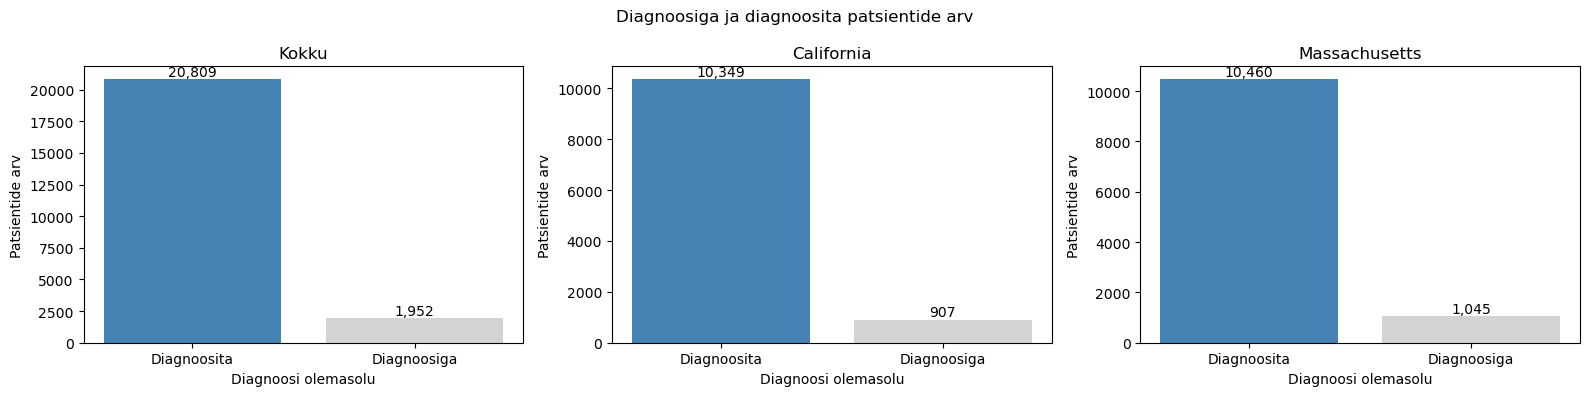

In [26]:
def diag_counts(state_code=None):
    where = "WHERE p.state = %(state)s" if state_code else ""
    return pd.read_sql(f"""
        SELECT
            CASE WHEN condition_count > 0 THEN 'Diagnoosiga' ELSE 'Diagnoosita' END AS diagnoos,
            COUNT(*) AS patsientide_arv
        FROM (
            SELECT p.patient_id, COUNT(fwr.snomed_code) AS condition_count
            FROM raw_marts.dim_patients p
            LEFT JOIN raw_marts.fct_patient_weather_region fwr ON fwr.patient_id = p.patient_id
            {where}
            GROUP BY p.patient_id
        ) t
        GROUP BY diagnoos
    """, engine, params={"state": state_code} if state_code else None).set_index("diagnoos")["patsientide_arv"]

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

for ax, (state_code, title) in zip(axes, [(None, 'Kokku'), ('CA', 'California'), ('MA', 'Massachusetts')]):
    data = diag_counts(state_code)
    bars = ax.bar(data.index, data.values, color=["steelblue", "lightgray"])
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 30,
                f'{int(bar.get_height()):,}', ha='center', va='bottom', fontsize=10)
    ax.set_title(title)
    ax.set_xlabel('Diagnoosi olemasolu')
    ax.set_ylabel('Patsientide arv')

plt.suptitle('Diagnoosiga ja diagnoosita patsientide arv')
plt.tight_layout()
plt.show()

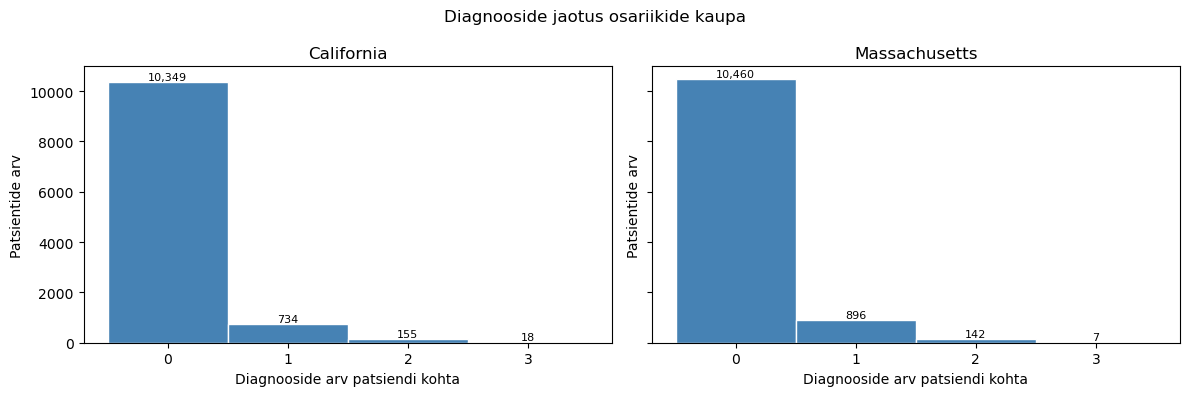

In [27]:
df_hist = pd.read_sql("""
    SELECT
        p.state,
        COUNT(fwr.snomed_code) AS condition_count
    FROM raw_marts.dim_patients p
    LEFT JOIN raw_marts.fct_patient_weather_region fwr
        ON fwr.patient_id = p.patient_id
    GROUP BY p.patient_id, p.state
""", engine)

fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)

for ax, (state, label) in zip(axes, [('CA', 'California'), ('MA', 'Massachusetts')]):
    data = df_hist[df_hist['state'] == state]['condition_count']
    max_val = int(data.max())
    bins = [x - 0.5 for x in range(0, max_val + 2)]
    n, _, patches = ax.hist(data, bins=bins, color='steelblue', edgecolor='white')
    for count, patch in zip(n, patches):
        if count > 0:
            ax.text(patch.get_x() + patch.get_width() / 2, count + 5,
                    f'{int(count):,}', ha='center', va='bottom', fontsize=8)
    ax.set_xticks(range(0, max_val + 1))
    ax.set_title(label)
    ax.set_xlabel('Diagnooside arv patsiendi kohta')
    ax.set_ylabel('Patsientide arv')

plt.suptitle('Diagnooside jaotus osariikide kaupa')
plt.tight_layout()
plt.show()

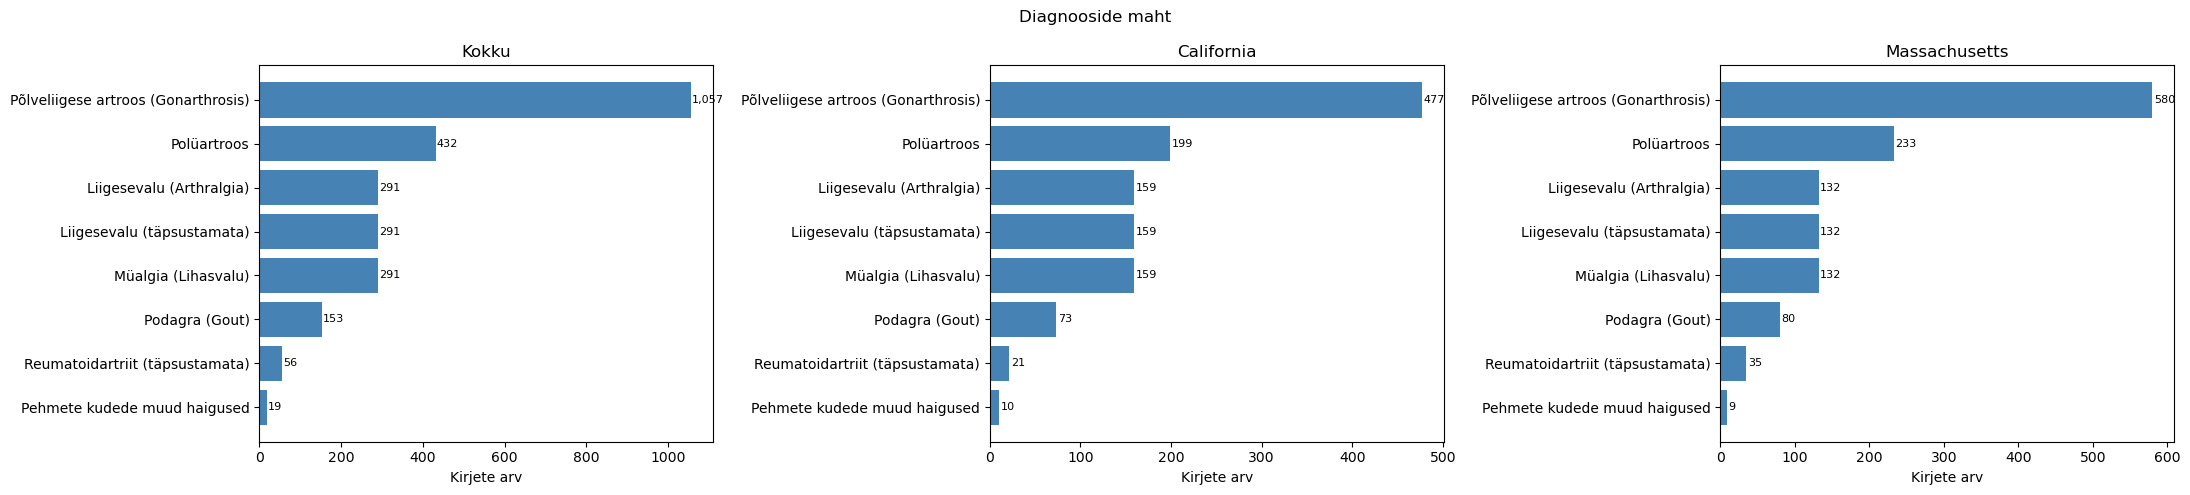

In [28]:
def diag_volume(state_code=None):
    where = "WHERE p.state = %(state)s" if state_code else ""
    return pd.read_sql(f"""
        SELECT d.diagnosis_name, COUNT(*) AS arv
        FROM raw_marts.fct_patient_weather_region fwr
        JOIN raw_marts.dim_diagnosis d ON d.snomed_code = fwr.snomed_code
        JOIN raw_marts.dim_patients p ON p.patient_id = fwr.patient_id
        {where}
        GROUP BY d.diagnosis_name
        ORDER BY arv DESC
    """, engine, params={"state": state_code} if state_code else None)

fig, axes = plt.subplots(1, 3, figsize=(22, 5))

for ax, (state_code, title) in zip(axes, [(None, 'Kokku'), ('CA', 'California'), ('MA', 'Massachusetts')]):
    data = diag_volume(state_code)
    bars = ax.barh(data['diagnosis_name'], data['arv'], color='steelblue')
    for bar in bars:
        ax.text(bar.get_width() + 2, bar.get_y() + bar.get_height() / 2,
                f'{int(bar.get_width()):,}', va='center', fontsize=8)
    ax.invert_yaxis()
    ax.set_title(title)
    ax.set_xlabel('Kirjete arv')

plt.suptitle('Diagnooside maht')
plt.tight_layout()
plt.show()

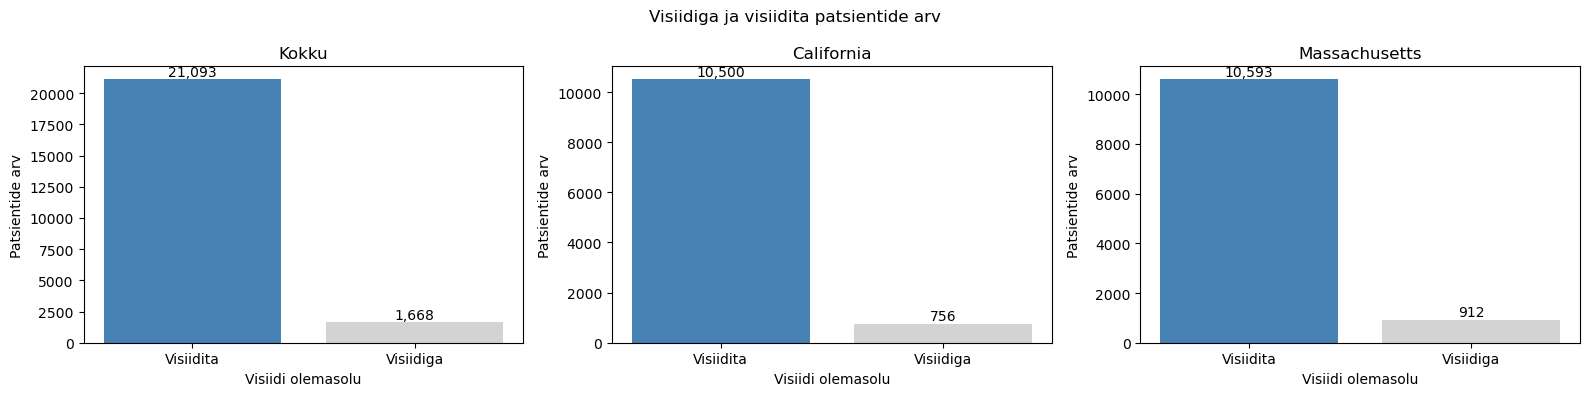

In [29]:
def visit_counts(state_code=None):
    where = "WHERE p.state = %(state)s" if state_code else ""
    return pd.read_sql(f"""
        SELECT
            CASE WHEN visit_count > 0 THEN 'Visiidiga' ELSE 'Visiidita' END AS visiit,
            COUNT(*) AS patsientide_arv
        FROM (
            SELECT p.patient_id, COUNT(DISTINCT fwr.encounter_id) AS visit_count
            FROM raw_marts.dim_patients p
            LEFT JOIN raw_marts.fct_patient_weather_region fwr ON fwr.patient_id = p.patient_id
            {where}
            GROUP BY p.patient_id
        ) t
        GROUP BY visiit
    """, engine, params={"state": state_code} if state_code else None).set_index("visiit")["patsientide_arv"]

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

for ax, (state_code, title) in zip(axes, [(None, 'Kokku'), ('CA', 'California'), ('MA', 'Massachusetts')]):
    data = visit_counts(state_code)
    bars = ax.bar(data.index, data.values, color=["steelblue", "lightgray"])
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 30,
                f'{int(bar.get_height()):,}', ha='center', va='bottom', fontsize=10)
    ax.set_title(title)
    ax.set_xlabel('Visiidi olemasolu')
    ax.set_ylabel('Patsientide arv')

plt.suptitle('Visiidiga ja visiidita patsientide arv')
plt.tight_layout()
plt.show()

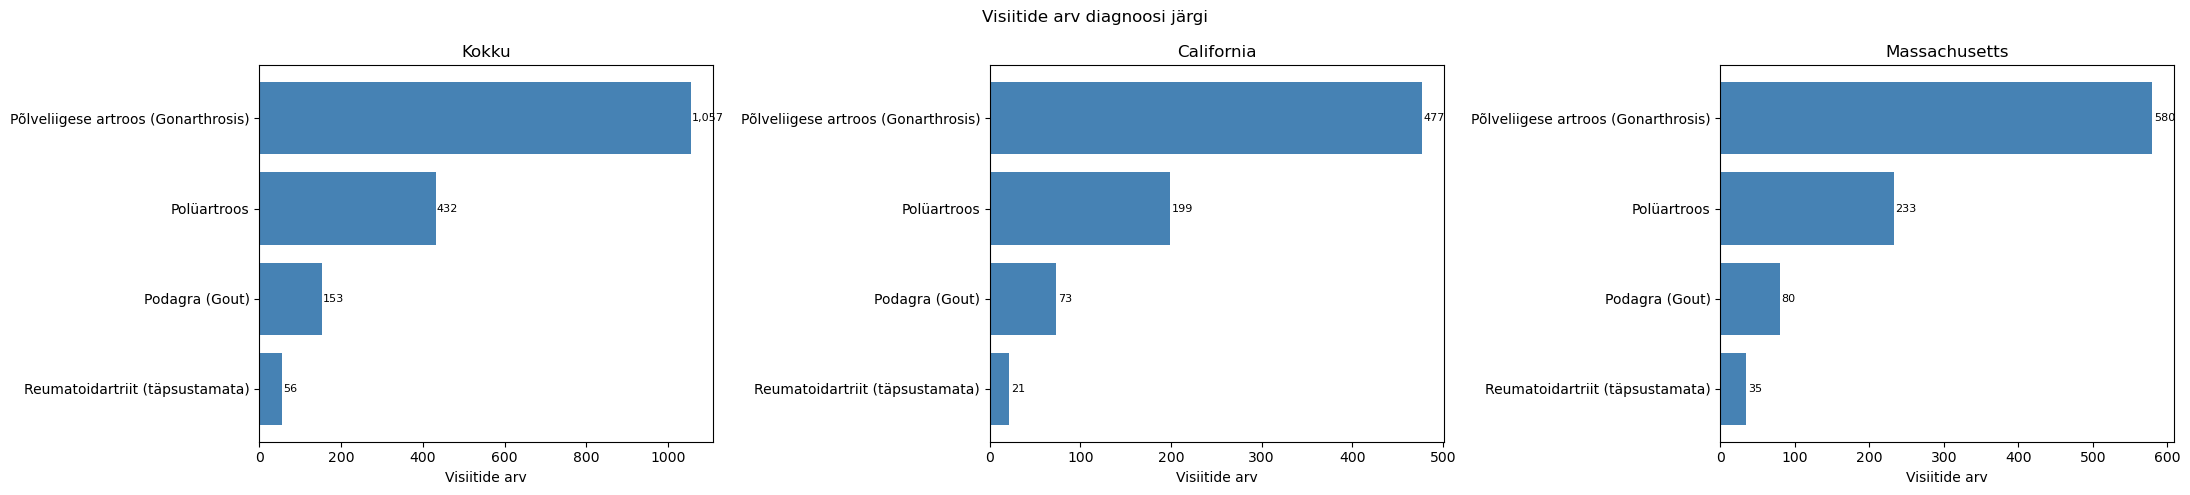

In [30]:
def visits_per_diag(state_code=None):
    where = "AND p.state = %(state)s" if state_code else ""
    return pd.read_sql(f"""
        SELECT d.diagnosis_name, COUNT(DISTINCT fwr.encounter_id) AS visiitide_arv
        FROM raw_marts.fct_patient_weather_region fwr
        JOIN raw_marts.dim_diagnosis d ON d.snomed_code = fwr.snomed_code
        JOIN raw_marts.dim_patients p ON p.patient_id = fwr.patient_id
        WHERE fwr.encounter_id IS NOT NULL {where}
        GROUP BY d.diagnosis_name
        ORDER BY visiitide_arv DESC
    """, engine, params={"state": state_code} if state_code else None)

fig, axes = plt.subplots(1, 3, figsize=(22, 5))

for ax, (state_code, title) in zip(axes, [(None, 'Kokku'), ('CA', 'California'), ('MA', 'Massachusetts')]):
    data = visits_per_diag(state_code)
    bars = ax.barh(data['diagnosis_name'], data['visiitide_arv'], color='steelblue')
    for bar in bars:
        ax.text(bar.get_width() + 2, bar.get_y() + bar.get_height() / 2,
                f'{int(bar.get_width()):,}', va='center', fontsize=8)
    ax.invert_yaxis()
    ax.set_title(title)
    ax.set_xlabel('Visiitide arv')

plt.suptitle('Visiitide arv diagnoosi järgi')
plt.tight_layout()
plt.show()

## Demograafiline jaotus

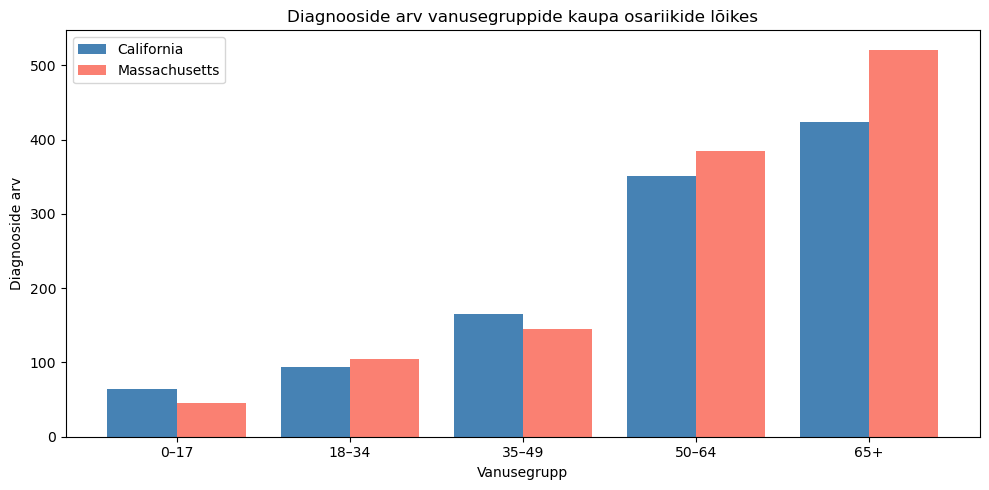

In [31]:
diag_age = pd.read_sql("""
    SELECT
        CASE
            WHEN DATE_PART('year', AGE(p.birthdate::date)) < 18  THEN '0–17'
            WHEN DATE_PART('year', AGE(p.birthdate::date)) < 35  THEN '18–34'
            WHEN DATE_PART('year', AGE(p.birthdate::date)) < 50  THEN '35–49'
            WHEN DATE_PART('year', AGE(p.birthdate::date)) < 65  THEN '50–64'
            ELSE '65+'
        END AS age_group,
        p.state,
        COUNT(*) AS count
    FROM raw_marts.fct_patient_weather_region fwr
    JOIN raw_marts.dim_patients p ON p.patient_id = fwr.patient_id
    WHERE fwr.condition_start IS NOT NULL
    GROUP BY age_group, p.state
""", engine)

age_order = ['0–17', '18–34', '35–49', '50–64', '65+']
ca = diag_age[diag_age['state'] == 'CA'].set_index('age_group')['count']
ma = diag_age[diag_age['state'] == 'MA'].set_index('age_group')['count']

x = range(len(age_order))
width = 0.4

plt.figure(figsize=(10, 5))
plt.bar([i - width/2 for i in x], [ca.get(s, 0) for s in age_order], width=width, label='California', color='steelblue')
plt.bar([i + width/2 for i in x], [ma.get(s, 0) for s in age_order], width=width, label='Massachusetts', color='salmon')
plt.xticks(x, age_order)
plt.title('Diagnooside arv vanusegruppide kaupa osariikide lõikes')
plt.xlabel('Vanusegrupp')
plt.ylabel('Diagnooside arv')
plt.legend()
plt.tight_layout()
plt.show()

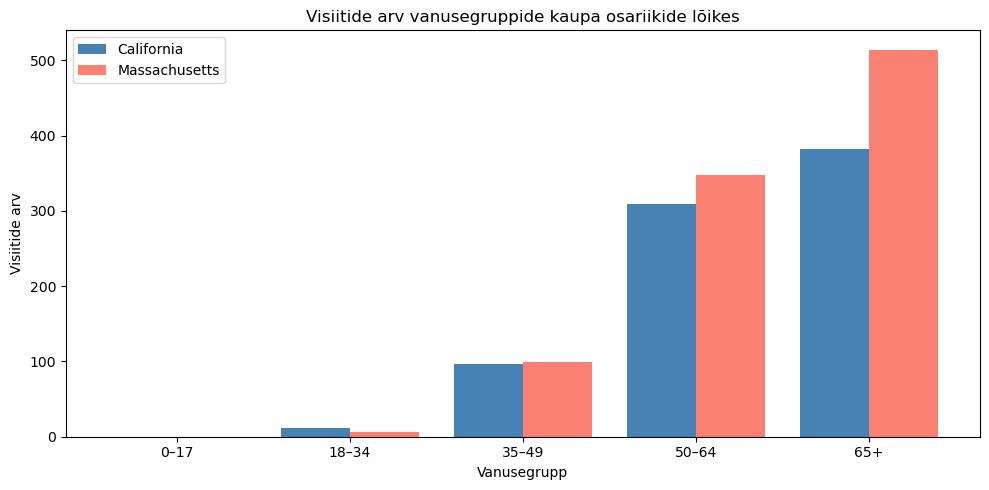

In [32]:
visit_age = pd.read_sql("""
    SELECT
        CASE
            WHEN DATE_PART('year', AGE(p.birthdate::date)) < 18  THEN '0–17'
            WHEN DATE_PART('year', AGE(p.birthdate::date)) < 35  THEN '18–34'
            WHEN DATE_PART('year', AGE(p.birthdate::date)) < 50  THEN '35–49'
            WHEN DATE_PART('year', AGE(p.birthdate::date)) < 65  THEN '50–64'
            ELSE '65+'
        END AS age_group,
        p.state,
        COUNT(DISTINCT e.encounter_id) AS count
    FROM raw.encounters e
    JOIN raw_marts.dim_patients p ON p.patient_id = e.patient_id
    WHERE e.period_start IS NOT NULL
    GROUP BY age_group, p.state
""", engine)

age_order = ['0–17', '18–34', '35–49', '50–64', '65+']
ca = visit_age[visit_age['state'] == 'CA'].set_index('age_group')['count']
ma = visit_age[visit_age['state'] == 'MA'].set_index('age_group')['count']

x = range(len(age_order))
width = 0.4

plt.figure(figsize=(10, 5))
plt.bar([i - width/2 for i in x], [ca.get(s, 0) for s in age_order], width=width, label='California', color='steelblue')
plt.bar([i + width/2 for i in x], [ma.get(s, 0) for s in age_order], width=width, label='Massachusetts', color='salmon')
plt.xticks(x, age_order)
plt.title('Visiitide arv vanusegruppide kaupa osariikide lõikes')
plt.xlabel('Vanusegrupp')
plt.ylabel('Visiitide arv')
plt.legend()
plt.tight_layout()
plt.show()

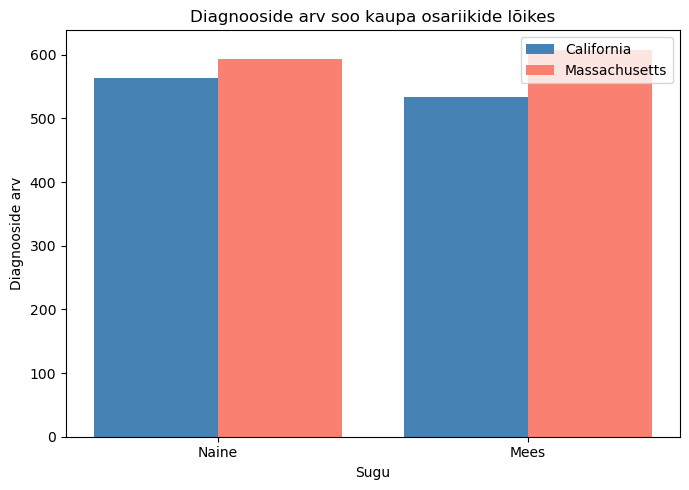

In [33]:
diag_gender = pd.read_sql("""
    SELECT
        p.gender,
        p.state,
        COUNT(*) AS count
    FROM raw_marts.fct_patient_weather_region fwr
    JOIN raw_marts.dim_patients p ON p.patient_id = fwr.patient_id
    WHERE fwr.condition_start IS NOT NULL
    GROUP BY p.gender, p.state
""", engine)

gender_order = ['female', 'male']
gender_labels = ['Naine', 'Mees']
ca = diag_gender[diag_gender['state'] == 'CA'].set_index('gender')['count']
ma = diag_gender[diag_gender['state'] == 'MA'].set_index('gender')['count']

x = range(len(gender_order))
width = 0.4

plt.figure(figsize=(7, 5))
plt.bar([i - width/2 for i in x], [ca.get(s, 0) for s in gender_order], width=width, label='California', color='steelblue')
plt.bar([i + width/2 for i in x], [ma.get(s, 0) for s in gender_order], width=width, label='Massachusetts', color='salmon')
plt.xticks(x, gender_labels)
plt.title('Diagnooside arv soo kaupa osariikide lõikes')
plt.xlabel('Sugu')
plt.ylabel('Diagnooside arv')
plt.legend()
plt.tight_layout()
plt.show()

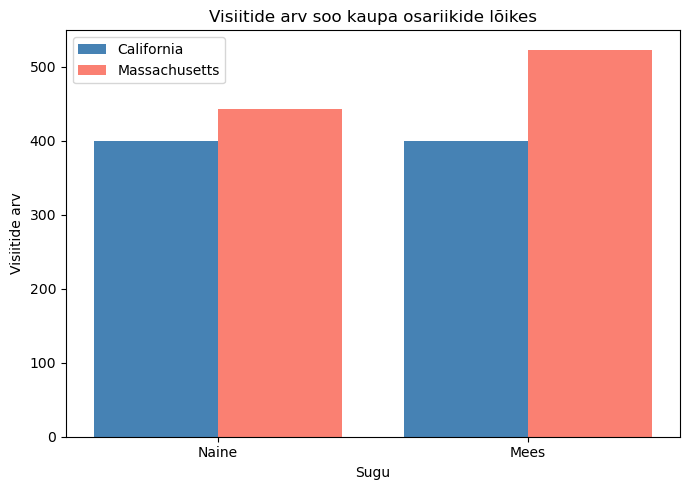

In [34]:
visit_gender = pd.read_sql("""
    SELECT
        p.gender,
        p.state,
        COUNT(DISTINCT e.encounter_id) AS count
    FROM raw.encounters e
    JOIN raw_marts.dim_patients p ON p.patient_id = e.patient_id
    WHERE e.period_start IS NOT NULL
    GROUP BY p.gender, p.state
""", engine)

gender_order = ['female', 'male']
gender_labels = ['Naine', 'Mees']
ca = visit_gender[visit_gender['state'] == 'CA'].set_index('gender')['count']
ma = visit_gender[visit_gender['state'] == 'MA'].set_index('gender')['count']

x = range(len(gender_order))
width = 0.4

plt.figure(figsize=(7, 5))
plt.bar([i - width/2 for i in x], [ca.get(s, 0) for s in gender_order], width=width, label='California', color='steelblue')
plt.bar([i + width/2 for i in x], [ma.get(s, 0) for s in gender_order], width=width, label='Massachusetts', color='salmon')
plt.xticks(x, gender_labels)
plt.title('Visiitide arv soo kaupa osariikide lõikes')
plt.xlabel('Sugu')
plt.ylabel('Visiitide arv')
plt.legend()
plt.tight_layout()
plt.show()

## Ajaline jaotus

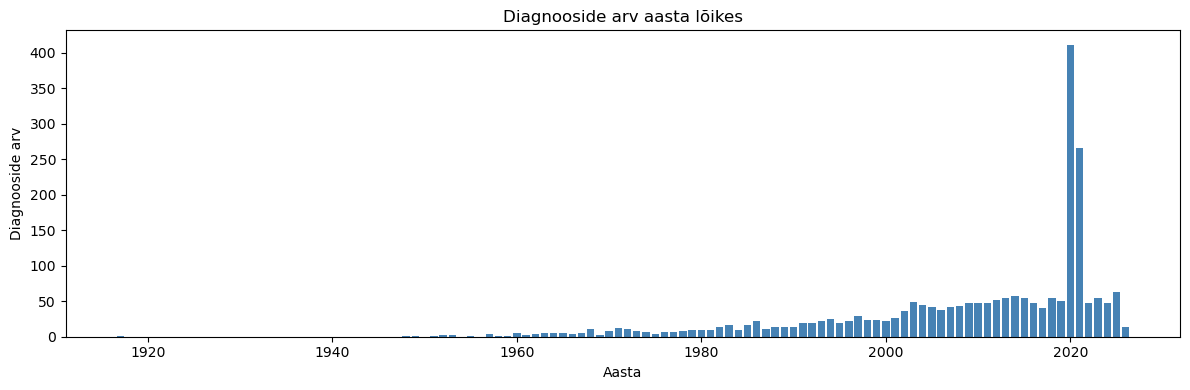

In [35]:
diag_by_year = pd.read_sql("""
    SELECT
        EXTRACT(YEAR FROM condition_start::date) AS year,
        COUNT(*) AS condition_count
    FROM raw_marts.fct_patient_weather_region
    WHERE condition_start IS NOT NULL
    GROUP BY year
    ORDER BY year
""", engine)

plt.figure(figsize=(12, 4))
plt.bar(diag_by_year["year"], diag_by_year["condition_count"], color="steelblue")
plt.title("Diagnooside arv aasta lõikes")
plt.xlabel("Aasta")
plt.ylabel("Diagnooside arv")
plt.tight_layout()
plt.show()

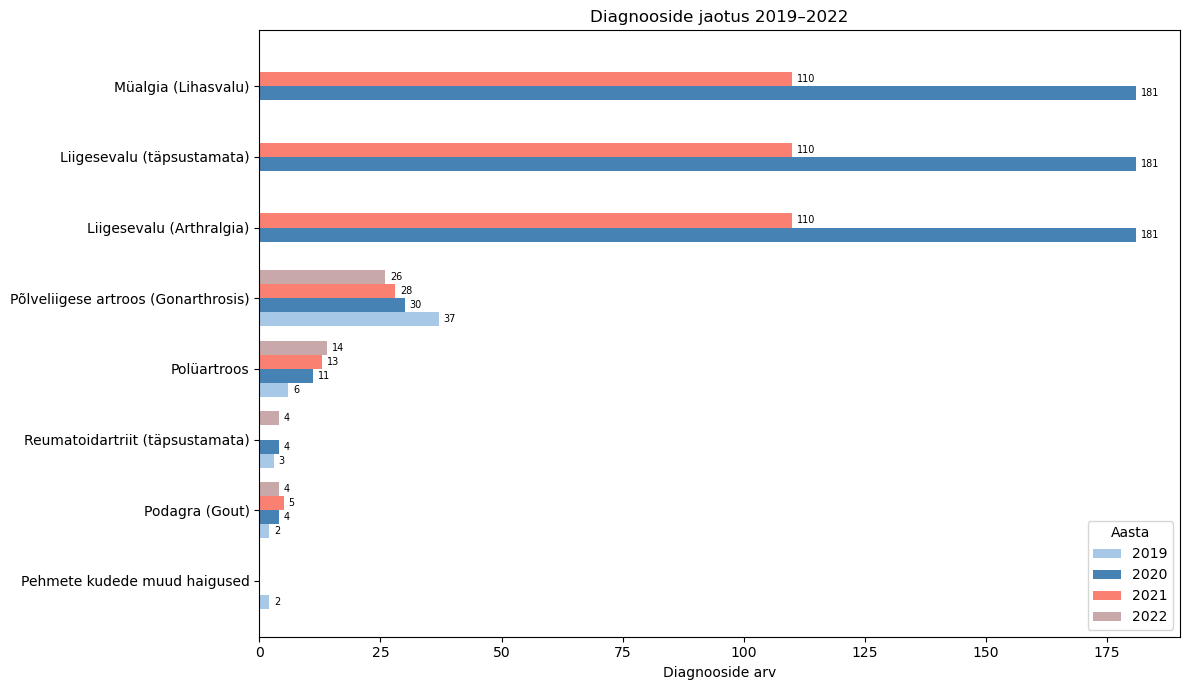

In [36]:
df_years = pd.read_sql("""
    SELECT
        EXTRACT(YEAR FROM condition_start::date) AS year,
        d.diagnosis_name,
        COUNT(*) AS arv
    FROM raw_marts.fct_patient_weather_region fwr
    JOIN raw_marts.dim_diagnosis d ON d.snomed_code = fwr.snomed_code
    WHERE EXTRACT(YEAR FROM condition_start::date) IN (2019, 2020, 2021, 2022)
    GROUP BY year, d.diagnosis_name
    ORDER BY year, arv DESC
""", engine)

pivot = df_years.pivot(index='diagnosis_name', columns='year', values='arv').fillna(0)
pivot = pivot.sort_values(2020, ascending=True)

years = [2019, 2020, 2021, 2022]
colors = ['#a8c8e8', 'steelblue', 'salmon', '#c8a8a8']
n = len(pivot)
width = 0.2

fig, ax = plt.subplots(figsize=(12, 7))
for i, (year, color) in enumerate(zip(years, colors)):
    offsets = [j + (i - 1.5) * width for j in range(n)]
    bars = ax.barh(offsets, pivot[year], height=width, label=str(int(year)), color=color)
    for bar, val in zip(bars, pivot[year]):
        if val > 0:
            ax.text(bar.get_width() + 1, bar.get_y() + bar.get_height() / 2,
                    str(int(val)), va='center', fontsize=7)

ax.set_yticks(range(n))
ax.set_yticklabels(pivot.index)
ax.set_xlabel('Diagnooside arv')
ax.set_title('Diagnooside jaotus 2019–2022')
ax.legend(title='Aasta')
plt.tight_layout()
plt.show()

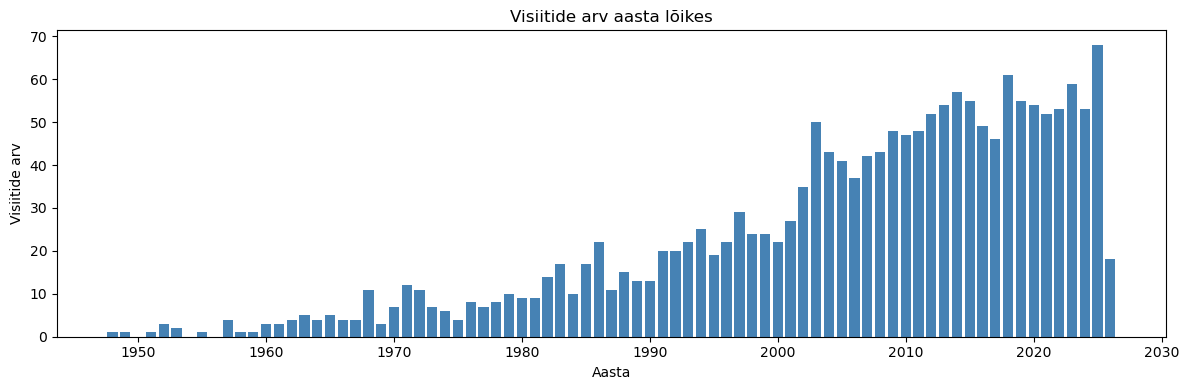

In [37]:
visits_by_year = pd.read_sql("""
    SELECT
        EXTRACT(YEAR FROM period_start) AS year,
        COUNT(DISTINCT encounter_id)    AS visit_count
    FROM raw.encounters
    GROUP BY year
    ORDER BY year
""", engine)

plt.figure(figsize=(12, 4))
plt.bar(visits_by_year["year"], visits_by_year["visit_count"], color="steelblue")
plt.title("Visiitide arv aasta lõikes")
plt.xlabel("Aasta")
plt.ylabel("Visiitide arv")
plt.tight_layout()
plt.show()

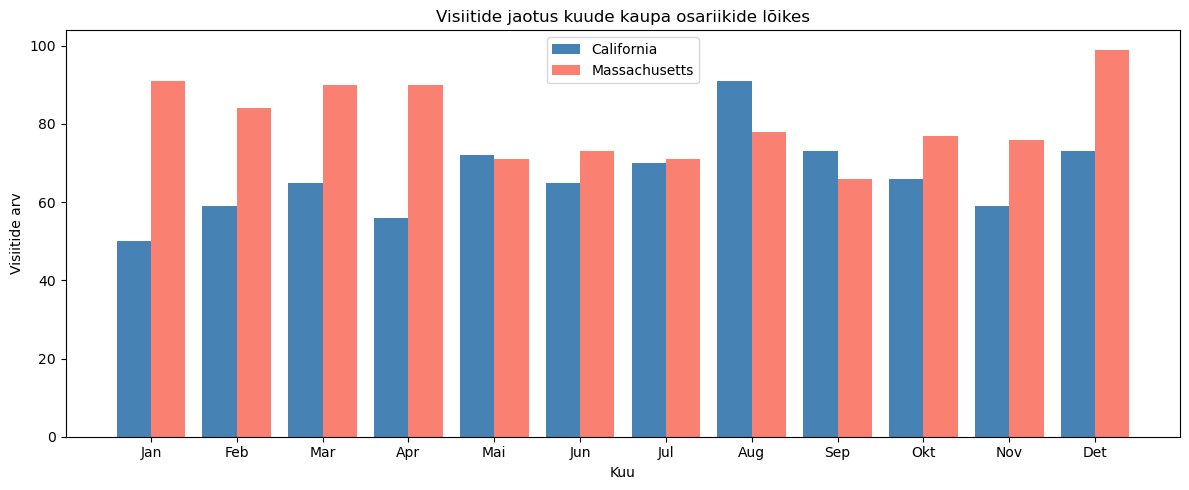

In [38]:
monthly = pd.read_sql("""
    SELECT
        EXTRACT(MONTH FROM e.period_start) AS month,
        p.state,
        COUNT(DISTINCT e.encounter_id) AS count
    FROM raw.encounters e
    JOIN raw_marts.dim_patients p ON p.patient_id = e.patient_id
    WHERE e.period_start IS NOT NULL
    GROUP BY month, p.state
    ORDER BY month
""", engine)

ca = monthly[monthly['state'] == 'CA'].set_index('month')['count']
ma = monthly[monthly['state'] == 'MA'].set_index('month')['count']

x = range(1, 13)
width = 0.4

plt.figure(figsize=(12, 5))
plt.bar([m - width/2 for m in x], [ca.get(m, 0) for m in x], width=width, label='California', color='steelblue')
plt.bar([m + width/2 for m in x], [ma.get(m, 0) for m in x], width=width, label='Massachusetts', color='salmon')
plt.xticks(range(1, 13), ['Jan', 'Feb', 'Mar', 'Apr', 'Mai', 'Jun', 'Jul', 'Aug', 'Sep', 'Okt', 'Nov', 'Det'])
plt.title('Visiitide jaotus kuude kaupa osariikide lõikes')
plt.xlabel('Kuu')
plt.ylabel('Visiitide arv')
plt.legend()
plt.tight_layout()
plt.show()

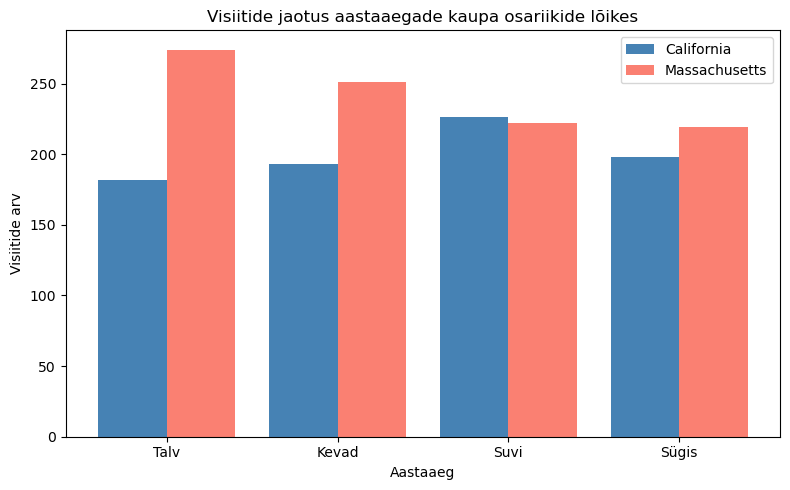

In [39]:
seasonal = pd.read_sql("""
    SELECT
        CASE
            WHEN EXTRACT(MONTH FROM e.period_start) IN (12, 1, 2) THEN 'Talv'
            WHEN EXTRACT(MONTH FROM e.period_start) IN (3, 4, 5)  THEN 'Kevad'
            WHEN EXTRACT(MONTH FROM e.period_start) IN (6, 7, 8)  THEN 'Suvi'
            ELSE 'Sügis'
        END AS season,
        p.state,
        COUNT(DISTINCT e.encounter_id) AS count
    FROM raw.encounters e
    JOIN raw_marts.dim_patients p ON p.patient_id = e.patient_id
    WHERE e.period_start IS NOT NULL
    GROUP BY season, p.state
""", engine)

season_order = ['Talv', 'Kevad', 'Suvi', 'Sügis']
ca = seasonal[seasonal['state'] == 'CA'].set_index('season')['count']
ma = seasonal[seasonal['state'] == 'MA'].set_index('season')['count']

x = range(len(season_order))
width = 0.4

plt.figure(figsize=(8, 5))
plt.bar([i - width/2 for i in x], [ca.get(s, 0) for s in season_order], width=width, label='California', color='steelblue')
plt.bar([i + width/2 for i in x], [ma.get(s, 0) for s in season_order], width=width, label='Massachusetts', color='salmon')
plt.xticks(x, season_order)
plt.title('Visiitide jaotus aastaaegade kaupa osariikide lõikes')
plt.xlabel('Aastaaeg')
plt.ylabel('Visiitide arv')
plt.legend()
plt.tight_layout()
plt.show()

## Ilmatunnuste seos visiitidega

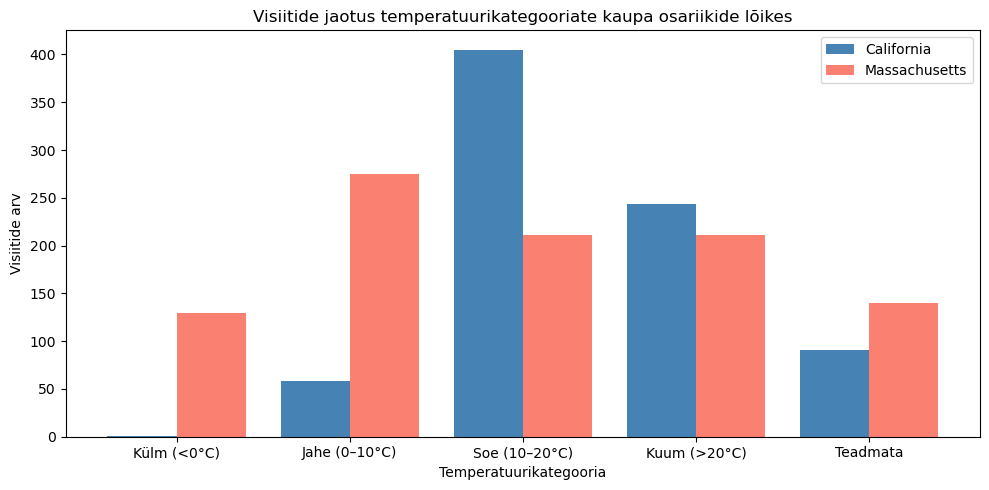

In [40]:
temp_counts = pd.read_sql("""
    SELECT
        CASE
            WHEN w.tavg IS NULL THEN 'Teadmata'
            WHEN w.tavg < 0     THEN 'Külm (<0°C)'
            WHEN w.tavg < 10    THEN 'Jahe (0–10°C)'
            WHEN w.tavg < 20    THEN 'Soe (10–20°C)'
            ELSE                     'Kuum (>20°C)'
        END AS temp_cat,
        p.state,
        COUNT(DISTINCT e.encounter_id) AS count
    FROM raw.encounters e
    JOIN raw_marts.dim_patients p ON p.patient_id = e.patient_id
    LEFT JOIN raw_marts.fct_patient_weather_region fwr ON fwr.encounter_id = e.encounter_id
    LEFT JOIN raw_marts.dim_region r ON r.region_key = fwr.region_key
    LEFT JOIN raw.weather w ON w.lat = r.latitude AND w.lon = r.longitude
        AND w.date = e.period_start::date
    WHERE e.period_start IS NOT NULL
    GROUP BY temp_cat, p.state
""", engine)

temp_order = ['Külm (<0°C)', 'Jahe (0–10°C)', 'Soe (10–20°C)', 'Kuum (>20°C)', 'Teadmata']
ca = temp_counts[temp_counts['state'] == 'CA'].set_index('temp_cat')['count']
ma = temp_counts[temp_counts['state'] == 'MA'].set_index('temp_cat')['count']

x = range(len(temp_order))
width = 0.4

plt.figure(figsize=(10, 5))
plt.bar([i - width/2 for i in x], [ca.get(s, 0) for s in temp_order], width=width, label='California', color='steelblue')
plt.bar([i + width/2 for i in x], [ma.get(s, 0) for s in temp_order], width=width, label='Massachusetts', color='salmon')
plt.xticks(x, temp_order)
plt.title('Visiitide jaotus temperatuurikategooriate kaupa osariikide lõikes')
plt.xlabel('Temperatuurikategooria')
plt.ylabel('Visiitide arv')
plt.legend()
plt.tight_layout()
plt.show()

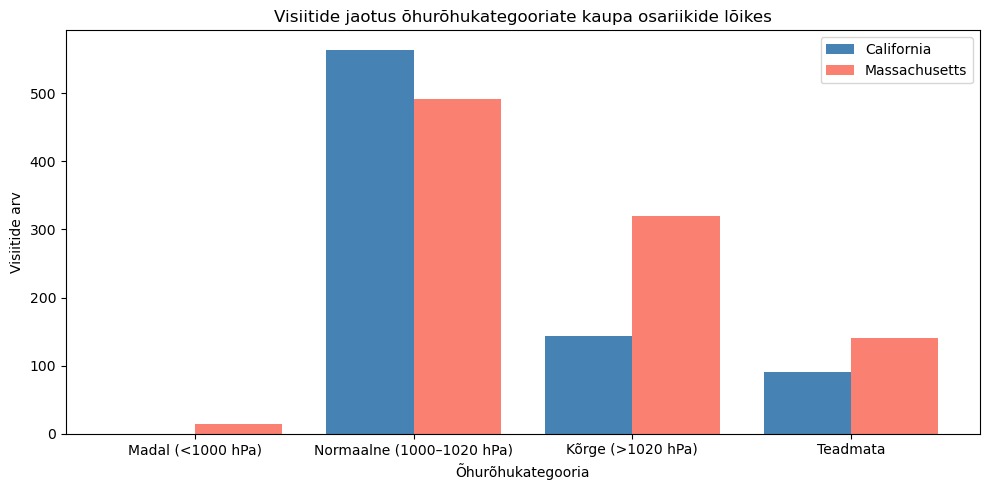

In [41]:
pres_counts = pd.read_sql("""
    SELECT
        CASE
            WHEN w.pres IS NULL THEN 'Teadmata'
            WHEN w.pres < 1000  THEN 'Madal (<1000 hPa)'
            WHEN w.pres <= 1020 THEN 'Normaalne (1000–1020 hPa)'
            ELSE                     'Kõrge (>1020 hPa)'
        END AS pres_cat,
        p.state,
        COUNT(DISTINCT e.encounter_id) AS count
    FROM raw.encounters e
    JOIN raw_marts.dim_patients p ON p.patient_id = e.patient_id
    LEFT JOIN raw_marts.fct_patient_weather_region fwr ON fwr.encounter_id = e.encounter_id
    LEFT JOIN raw_marts.dim_region r ON r.region_key = fwr.region_key
    LEFT JOIN raw.weather w ON w.lat = r.latitude AND w.lon = r.longitude
        AND w.date = e.period_start::date
    WHERE e.period_start IS NOT NULL
    GROUP BY pres_cat, p.state
""", engine)

pres_order = ['Madal (<1000 hPa)', 'Normaalne (1000–1020 hPa)', 'Kõrge (>1020 hPa)', 'Teadmata']
ca = pres_counts[pres_counts['state'] == 'CA'].set_index('pres_cat')['count']
ma = pres_counts[pres_counts['state'] == 'MA'].set_index('pres_cat')['count']

x = range(len(pres_order))
width = 0.4

plt.figure(figsize=(10, 5))
plt.bar([i - width/2 for i in x], [ca.get(s, 0) for s in pres_order], width=width, label='California', color='steelblue')
plt.bar([i + width/2 for i in x], [ma.get(s, 0) for s in pres_order], width=width, label='Massachusetts', color='salmon')
plt.xticks(x, pres_order)
plt.title('Visiitide jaotus õhurõhukategooriate kaupa osariikide lõikes')
plt.xlabel('Õhurõhukategooria')
plt.ylabel('Visiitide arv')
plt.legend()
plt.tight_layout()
plt.show()

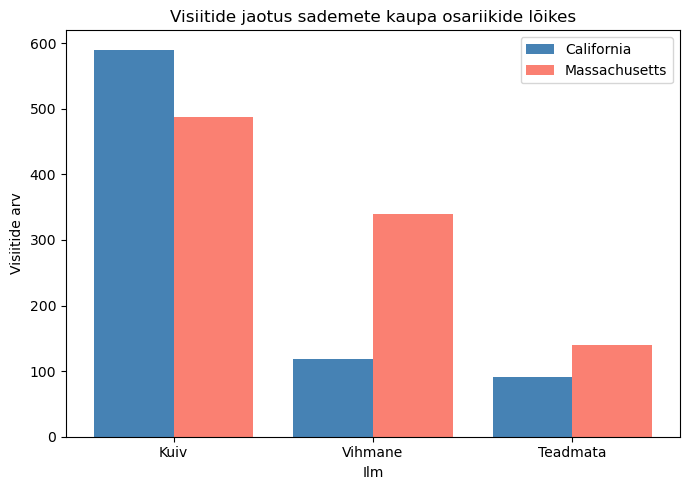

In [42]:
rain_counts = pd.read_sql("""
    SELECT
        CASE
            WHEN w.prcp IS NULL THEN 'Teadmata'
            WHEN w.prcp > 0     THEN 'Vihmane'
            ELSE                     'Kuiv'
        END AS rain_label,
        p.state,
        COUNT(DISTINCT e.encounter_id) AS count
    FROM raw.encounters e
    JOIN raw_marts.dim_patients p ON p.patient_id = e.patient_id
    LEFT JOIN raw_marts.fct_patient_weather_region fwr ON fwr.encounter_id = e.encounter_id
    LEFT JOIN raw_marts.dim_region r ON r.region_key = fwr.region_key
    LEFT JOIN raw.weather w ON w.lat = r.latitude AND w.lon = r.longitude
        AND w.date = e.period_start::date
    WHERE e.period_start IS NOT NULL
    GROUP BY rain_label, p.state
""", engine)

rain_order = ['Kuiv', 'Vihmane', 'Teadmata']
ca = rain_counts[rain_counts['state'] == 'CA'].set_index('rain_label')['count']
ma = rain_counts[rain_counts['state'] == 'MA'].set_index('rain_label')['count']

x = range(len(rain_order))
width = 0.4

plt.figure(figsize=(7, 5))
plt.bar([i - width/2 for i in x], [ca.get(s, 0) for s in rain_order], width=width, label='California', color='steelblue')
plt.bar([i + width/2 for i in x], [ma.get(s, 0) for s in rain_order], width=width, label='Massachusetts', color='salmon')
plt.xticks(x, rain_order)
plt.title('Visiitide jaotus sademete kaupa osariikide lõikes')
plt.xlabel('Ilm')
plt.ylabel('Visiitide arv')
plt.legend()
plt.tight_layout()
plt.show()

# Statistiline analüüs

In [43]:
def cramers_v(x, y):
    ct = pd.crosstab(x, y)
    chi2, p, _, _ = chi2_contingency(ct)
    n = ct.sum().sum()
    k = min(ct.shape) - 1
    v = np.sqrt(chi2 / (n * k)) if k > 0 else 0
    return v, p

df_pat = pd.read_sql("""
    SELECT
        p.gender,
        p.state,
        CASE
            WHEN DATE_PART('year', AGE(p.birthdate::date)) < 18  THEN '0–17'
            WHEN DATE_PART('year', AGE(p.birthdate::date)) < 35  THEN '18–34'
            WHEN DATE_PART('year', AGE(p.birthdate::date)) < 50  THEN '35–49'
            WHEN DATE_PART('year', AGE(p.birthdate::date)) < 65  THEN '50–64'
            ELSE '65+'
        END AS age_group,
        CASE WHEN COUNT(fwr.encounter_id) > 0 THEN 'Jah' ELSE 'Ei' END AS has_visit
    FROM raw_marts.dim_patients p
    LEFT JOIN raw_marts.fct_patient_weather_region fwr ON fwr.patient_id = p.patient_id
    GROUP BY p.patient_id, p.gender, p.state, p.birthdate
""", engine)

df_v = pd.read_sql("""
    SELECT
        fwr.snomed_code,
        p.state,
        CASE
            WHEN DATE_PART('year', AGE(p.birthdate::date)) < 18  THEN '0–17'
            WHEN DATE_PART('year', AGE(p.birthdate::date)) < 35  THEN '18–34'
            WHEN DATE_PART('year', AGE(p.birthdate::date)) < 50  THEN '35–49'
            WHEN DATE_PART('year', AGE(p.birthdate::date)) < 65  THEN '50–64'
            ELSE '65+'
        END AS age_group,
        EXTRACT(YEAR FROM fwr.condition_start::date)  AS year,
        EXTRACT(MONTH FROM fwr.condition_start::date) AS month,
        CASE
            WHEN w.tavg IS NULL THEN 'Teadmata'
            WHEN w.tavg < 0     THEN 'Külm (<0°C)'
            WHEN w.tavg < 10    THEN 'Jahe (0–10°C)'
            WHEN w.tavg < 20    THEN 'Soe (10–20°C)'
            ELSE                     'Kuum (>20°C)'
        END AS temp_cat,
        CASE
            WHEN w.pres IS NULL THEN 'Teadmata'
            WHEN w.pres < 1000  THEN 'Madal (<1000 hPa)'
            WHEN w.pres <= 1020 THEN 'Normaalne (1000–1020 hPa)'
            ELSE                     'Kõrge (>1020 hPa)'
        END AS pres_cat,
        CASE WHEN fwr.rainy_day_flag = TRUE THEN 'Vihmane' ELSE 'Kuiv' END AS rain_cat
    FROM raw_marts.fct_patient_weather_region fwr
    JOIN raw_marts.dim_patients p ON p.patient_id = fwr.patient_id
    JOIN raw_marts.dim_region r ON r.region_key = fwr.region_key
    LEFT JOIN raw.weather w ON w.lat = r.latitude AND w.lon = r.longitude
        AND w.date = fwr.condition_start::date
    WHERE fwr.condition_start IS NOT NULL
""", engine)

results = []

for col, label in [('gender', 'Sugu'), ('state', 'Osariik'), ('age_group', 'Vanusegrupp')]:
    v, p = cramers_v(df_pat[col], df_pat['has_visit'])
    results.append({'Tunnus': label, 'Tase': 'Patsient', 'Cramér V': round(v, 4), 'p-väärtus': round(p, 4)})

for col, label in [
    ('month', 'Kuu'), ('year', 'Aasta'),
    ('age_group', 'Vanusegrupp'), ('temp_cat', 'Temp kategooria'),
    ('pres_cat', 'Rõhu kategooria'), ('rain_cat', 'Sademed'),
    ('state', 'Osariik')
]:
    v, p = cramers_v(df_v[col].astype(str), df_v['snomed_code'].astype(str))
    results.append({'Tunnus': label, 'Tase': 'Diagnoos', 'Cramér V': round(v, 4), 'p-väärtus': round(p, 4)})

df_results = pd.DataFrame(results).sort_values('Cramér V', ascending=False)
df_results

,Tunnus,Tase,Cramér V,p-väärtus
2,Vanusegrupp,Patsient,0.2793,0.0000
4,Aasta,Diagnoos,0.2236,0.0887
5,Vanusegrupp,Diagnoos,0.1354,0.0000
3,Kuu,Diagnoos,0.0557,0.9952
6,Temp kategooria,Diagnoos,0.0457,0.5622
7,Rõhu kategooria,Diagnoos,0.0356,0.6969
9,Osariik,Diagnoos,0.0330,0.6047
1,Osariik,Patsient,0.0231,0.0005
8,Sademed,Diagnoos,0.0173,0.9171
0,Sugu,Patsient,0.0060,0.3623


**Statistiliselt olulised seosed (p < 0.05):**
- **Vanusegrupp (Patsient) V=0.28** — tugevaim seos: vanus ennustab kõige paremini, kas patsient käib visiidil
- **Vanusegrupp (Diagnoos) V=0.14** — vanus seostub ka diagnoosi tüübiga (noored vs vanad saavad erinevaid diagnoose)
- **Osariik (Patsient) V=0.02** — nõrk, kuid oluline: osariik mõjutab pisut visiidi tõenäosust

**Statistiliselt mitteolulised (p > 0.05):**
- Kõik ilmatunnused (temperatuur, rõhk, sademed) ei näita olulist seost diagnoosi tüübiga
- Kuu — diagnoosides pole selget hooajalisust
- Sugu — praktiliselt puudub seos visiidiga

**Aasta (Diagnoos) V=0.22, p=0.09** — trend on olemas, kuid andmeid on liiga vähe statistilise olulisuse saavutamiseks.

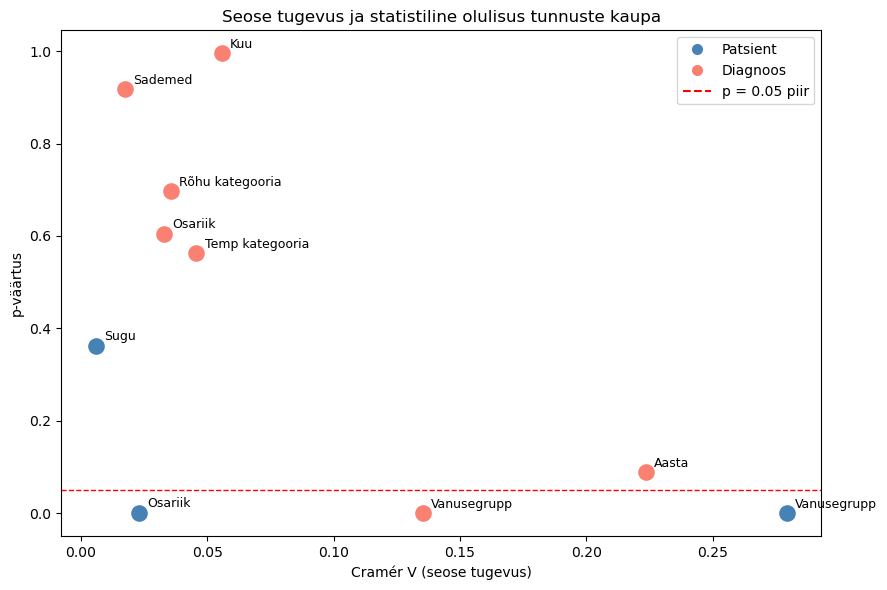

In [44]:
fig, ax = plt.subplots(figsize=(9, 6))

colors = {'Patsient': 'steelblue', 'Diagnoos': 'salmon'}

for _, row in df_results.iterrows():
    ax.scatter(row['Cramér V'], row['p-väärtus'],
               color=colors[row['Tase']], s=120, zorder=3)
    ax.annotate(row['Tunnus'], (row['Cramér V'], row['p-väärtus']),
                textcoords='offset points', xytext=(6, 4), fontsize=9)

ax.axhline(0.05, color='red', linestyle='--', linewidth=1, label='p = 0.05 piir')
ax.set_xlabel('Cramér V (seose tugevus)')
ax.set_ylabel('p-väärtus')
ax.set_title('Seose tugevus ja statistiline olulisus tunnuste kaupa')

legend_elements = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor='steelblue', markersize=9, label='Patsient'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='salmon', markersize=9, label='Diagnoos'),
    Line2D([0], [0], color='red', linestyle='--', label='p = 0.05 piir'),
]
ax.legend(handles=legend_elements)
plt.tight_layout()
plt.show()

Graafik näitab selgelt kolme rühma:

- **Paremas alanurgas (oluline ja tugev seos):** Vanusegrupp — nii visiidi kui diagnoosi puhul peamine selgitav tunnus
- **Vasakus alanurgas (oluline, nõrk seos):** Osariik (Patsient)
- **Üleval (mitteoluline):** kõik ilmatunnused, kuu ja sugu kobaravad vasakus ülanurgas — seos puudub või on juhuslik

**Peamine järeldus:** antud andmestikus on **vanus peamine tegur** — nii selles, kas patsient üldse käib visiidil, kui ka selles, milline diagnoos pannakse. Ilmastik ei näita statistiliselt olulist seost, mis on projekti seisukohast oluline leid.

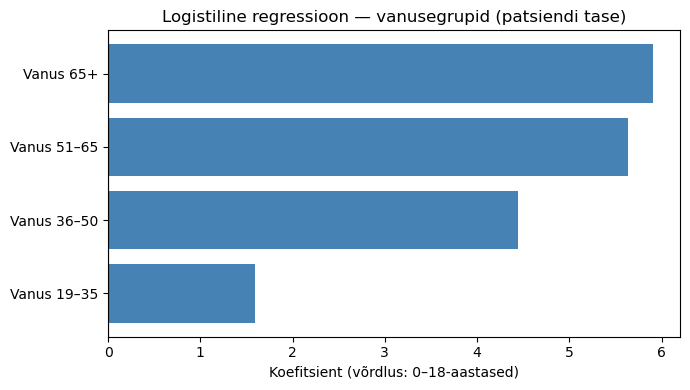

ROC AUC: 0.790  |  Täpsus: 64.70%


In [45]:
from sklearn.metrics import roc_auc_score

df_lr = pd.read_sql("""
    SELECT
        p.birthdate,
        CASE WHEN COUNT(fwr.encounter_id) > 0 THEN 1 ELSE 0 END AS has_visit
    FROM raw_marts.dim_patients p
    LEFT JOIN raw_marts.fct_patient_weather_region fwr
        ON fwr.patient_id = p.patient_id
    GROUP BY p.patient_id, p.birthdate
""", engine)

df_lr['age'] = (pd.Timestamp('today') - pd.to_datetime(df_lr['birthdate'])).dt.days / 365.25

df_lr['age_group'] = pd.cut(df_lr['age'],
    bins=[0, 18, 35, 50, 65, 150],
    labels=['0–18', '19–35', '36–50', '51–65', '65+'])

X2 = pd.get_dummies(df_lr['age_group'], prefix='age', drop_first=True).astype(float)
y2 = df_lr['has_visit']

model2 = LogisticRegression(max_iter=1000, class_weight='balanced')
model2.fit(X2, y2)

labels2 = {
    'age_19–35': 'Vanus 19–35',
    'age_36–50': 'Vanus 36–50',
    'age_51–65': 'Vanus 51–65',
    'age_65+':   'Vanus 65+',
}

coef2 = pd.DataFrame({
    'Tunnus': [labels2.get(f, f) for f in X2.columns],
    'Koefitsient': model2.coef_[0]
}).sort_values('Koefitsient')

plt.figure(figsize=(7, 4))
plt.barh(coef2['Tunnus'], coef2['Koefitsient'],
         color=['salmon' if v < 0 else 'steelblue' for v in coef2['Koefitsient']])
plt.axvline(0, color='black', linewidth=0.8)
plt.title('Logistiline regressioon — vanusegrupid (patsiendi tase)')
plt.xlabel('Koefitsient (võrdlus: 0–18-aastased)')
plt.tight_layout()
plt.show()

auc2 = roc_auc_score(y2, model2.predict_proba(X2)[:, 1])
print(f"ROC AUC: {auc2:.3f}  |  Täpsus: {model2.score(X2, y2):.2%}")

Visiidi tõenäosus kasvab vanusega järsult — eriti 35. eluaasta ümbruses. Vanemad patsiendid (36+) käivad arsti juures oluliselt sagedamini kui lapsed ja noored täiskasvanud. Vanus üksi selgitab 79% ulatuses, kes käib visiidil ja kes mitte (ROC AUC = 0.79).